In [ ]:
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARIMA
import numpy as np
import seaborn as sns
import pandas as pd
from statsmodels.tools.sm_exceptions import ValueWarning, HessianInversionWarning, ConvergenceWarning
import warnings

warnings.filterwarnings('ignore', category=ValueWarning)
warnings.filterwarnings('ignore', category=HessianInversionWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

<h2> Simulate Buying and Selling Stock Using ARMA(p,q)</h2>

In [ ]:
def run_simulation(returns, prices, amt, order, thresh, verbose=False, plot=True):
    if type(order) == float:
        thresh = None

    curr_holding = False
    events_list = []
    init_amt = amt

    for date, r in returns.iloc[14:].items():
        
        if curr_holding:
            sell_price = prices.loc[date]
            curr_holding = False
            ret = (sell_price - buy_price) / buy_price
            amt *= (1 + ret)
            events_list.append(('s', date, ret))
            
            if verbose:
                print('Sold at $%s' % sell_price)
                print('Predicted Return: %s' % round(pred, 4))
                print('Actual Return: %s' % (round(ret, 4)))
                print('=======================================')
            continue

        curr_data = returns[:date]
        
        if type(order) == tuple:
            try:
                model = ARIMA(curr_data, order=order).fit(maxiter=200)
                pred = model.forecast()[0][0]
            except:
                pred = thresh - 1

        if (not curr_holding) and \
        ((type(order) == float and np.random.random() < order) 
         or (type(order) == tuple and pred > thresh)
         or (order == 'last' and curr_data[-1] > 0)):
    
            curr_holding = True
            buy_price = prices.loc[date]
            events_list.append(('b', date))

            if verbose:
                print('Bought at $%s' % buy_price)
                
    if verbose:
        print('Total Amount: $%s' % round(amt, 2))

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(prices[14:])
        
        y_lims = (int(prices.min() * .95), int(prices.max() * 1.05))
        shaded_y_lims = int(prices.min() * .5), int(prices.max() * 1.5)

        for idx, event in enumerate(events_list):
            plt.axvline(event[1], color='k', linestyle='--', alpha=0.4)
            if event[0] == 's':
                color = 'green' if event[2] > 0 else 'red'
                plt.fill_betweenx(range(*shaded_y_lims), 
                                  event[1], events_list[idx-1][1], color=color, alpha=0.1)

        tot_return = round(100 * (amt / init_amt - 1), 2)
        tot_return = str(tot_return) + '%'
        plt.title("%s Price Data\nThresh=%s\nTotal Amt: $%s\nTotal Return: %s" % (tickerSymbol, thresh, round(amt, 2), tot_return), fontsize=20)
        plt.ylim(*y_lims)
        plt.show()

    return amt


<h2>Read Data  </h2>

In [5]:
tickerSymbol = 'AAPL'
data = yf.Ticker(tickerSymbol)

In [6]:
prices = data.history(start='2021-01-01', end='2021-04-01').Close
returns = prices.pct_change().dropna()

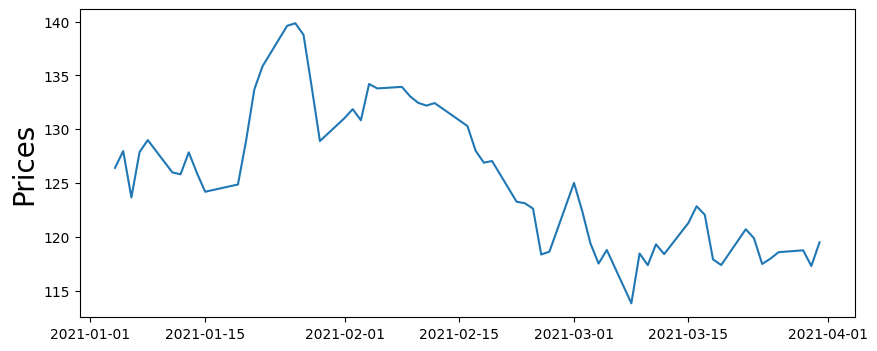

In [7]:
plt.figure(figsize=(10,4))
plt.plot(prices)
plt.ylabel('Prices', fontsize=20)
plt.show()

Text(0, 0.5, 'Return')

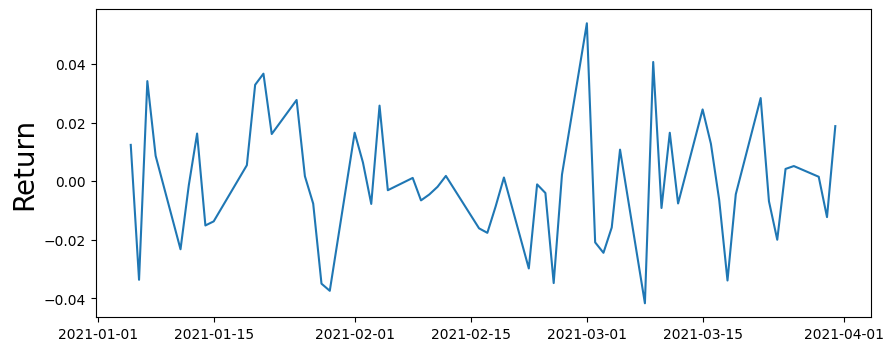

In [8]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.ylabel('Return', fontsize=20)

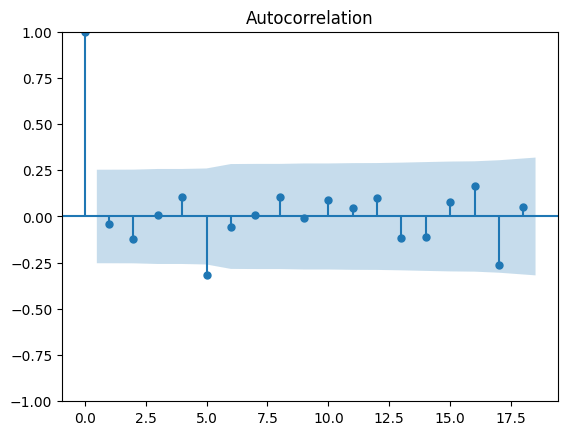

In [9]:
plot_acf(returns)
plt.show()

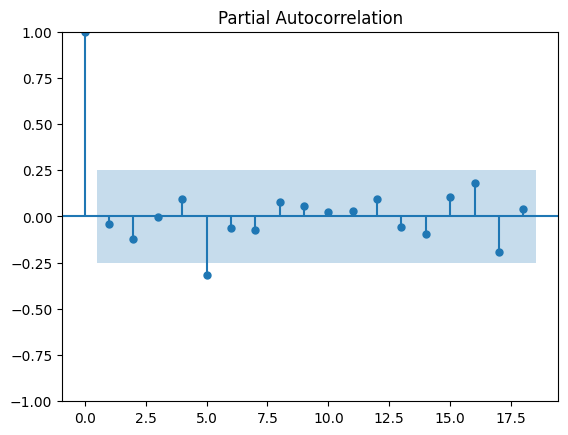

In [10]:
plot_pacf(returns)
plt.show()

<h2> Baseline Model : Random Buying </h2>

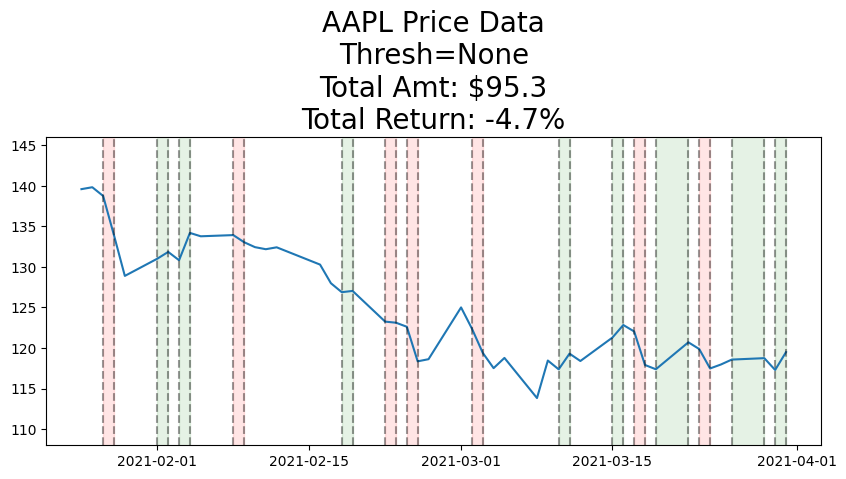

np.float64(95.29971145391683)

In [11]:
run_simulation(returns, prices, 100, 0.5, None, verbose=False)

In [12]:
final_amts = [run_simulation(returns, prices, 100, 0.5, None, verbose=False, plot=False) for _ in range(1000)]

C:\Users\rt\AppData\Local\Temp\ipykernel_17756\684952496.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(final_amts)


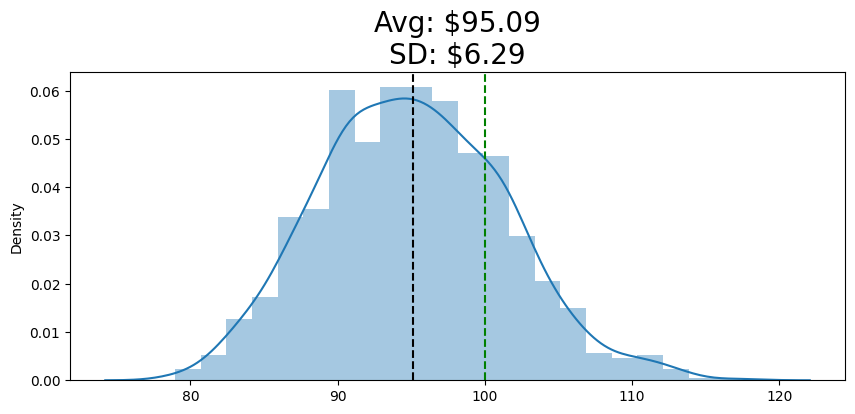

In [13]:
plt.figure(figsize=(10,4))
sns.distplot(final_amts)
plt.axvline(np.mean(final_amts), color='k', linestyle='--')
plt.axvline(100, color='g', linestyle='--')
plt.title('Avg: $%s\nSD: $%s'%(round(np.mean(final_amts),2), round(np.std(final_amts),2)), fontsize=20)
plt.show()

<h2> If Last Return was Positive, Buy </h2>

C:\Users\rt\AppData\Local\Temp\ipykernel_17756\2785939912.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  or (order == 'last' and curr_data[-1] > 0)):


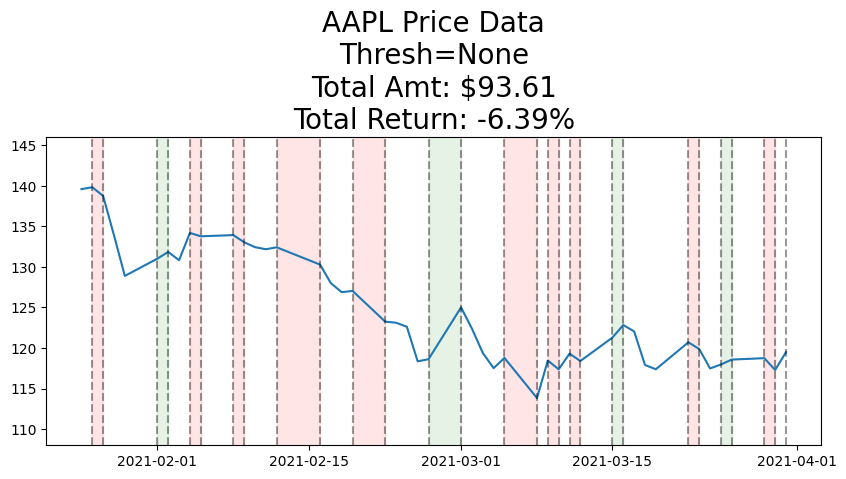

np.float64(93.6099293387501)

In [14]:
run_simulation(returns, prices, 100, 'last', None, verbose=False)

<h2> Try AR(1) Model </h2>

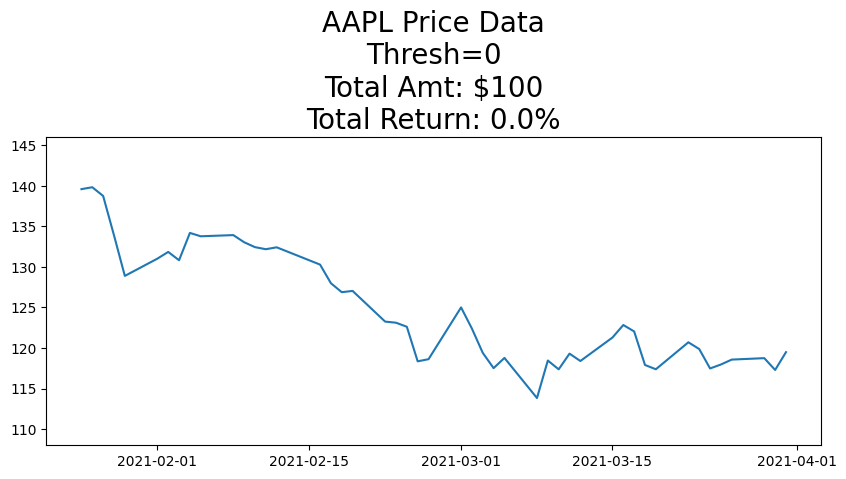

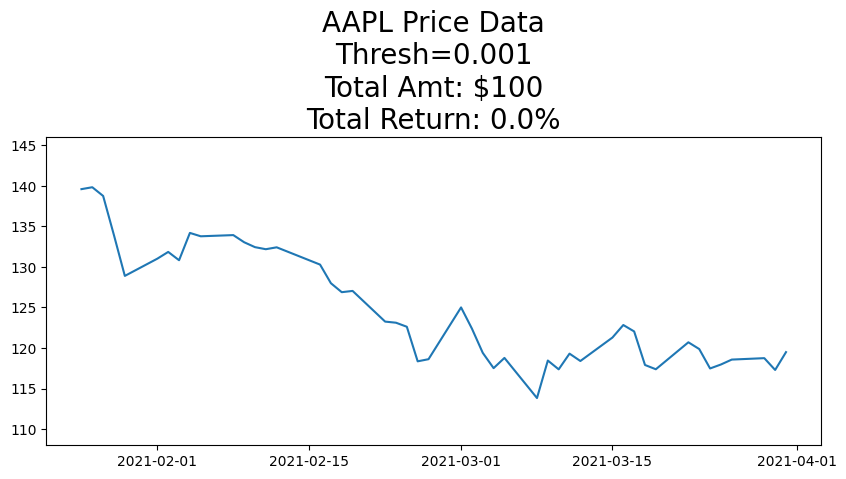

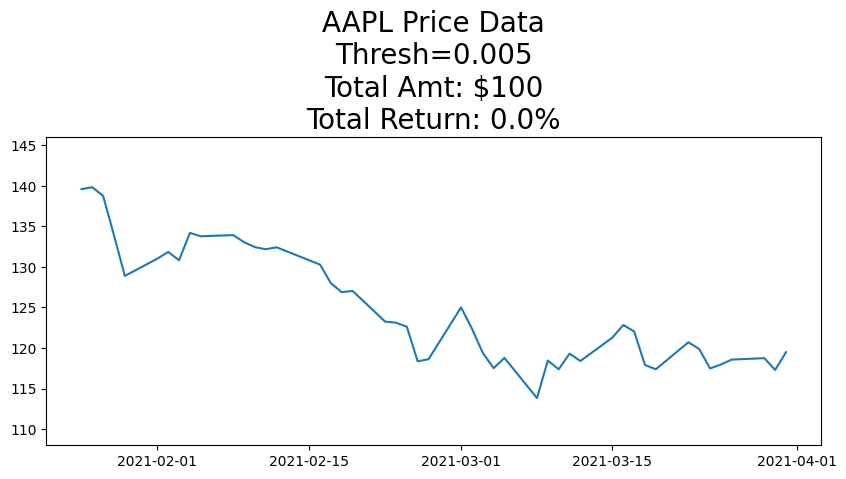

In [15]:
for thresh in [0, 0.001, 0.005]:
    run_simulation(returns, prices, 100, (1,0,0), thresh, verbose=False)

<h1> Try ARMA(5,5) Model </h2>

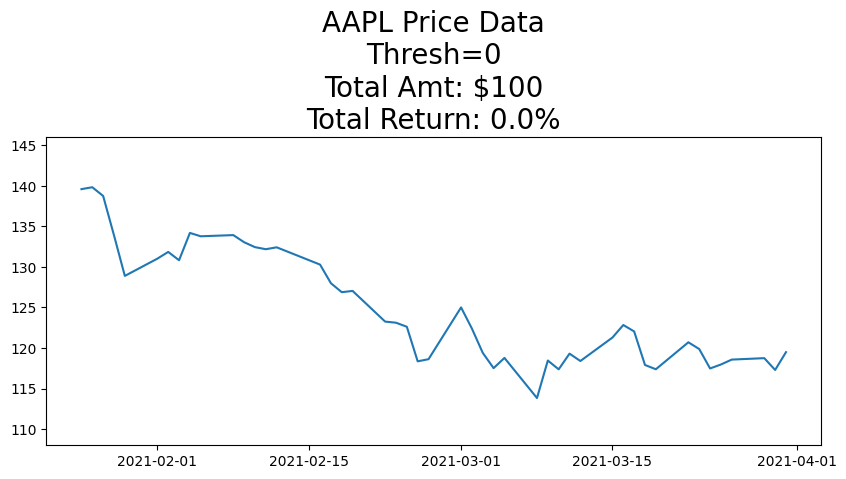

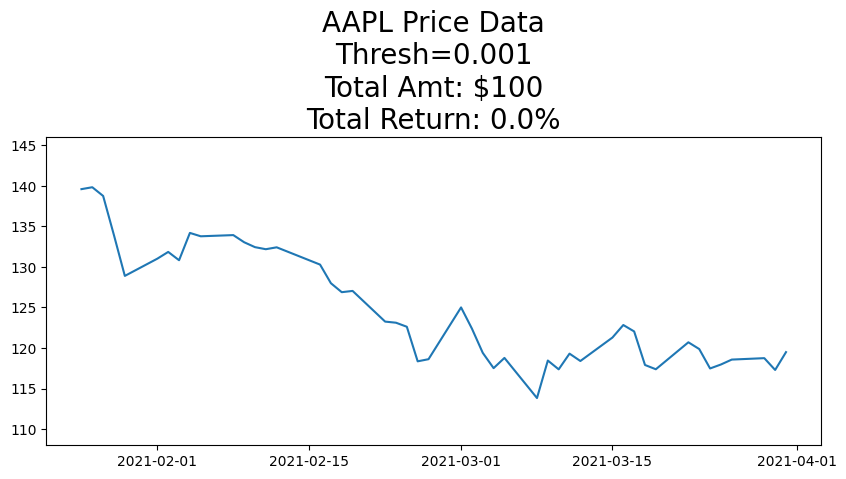

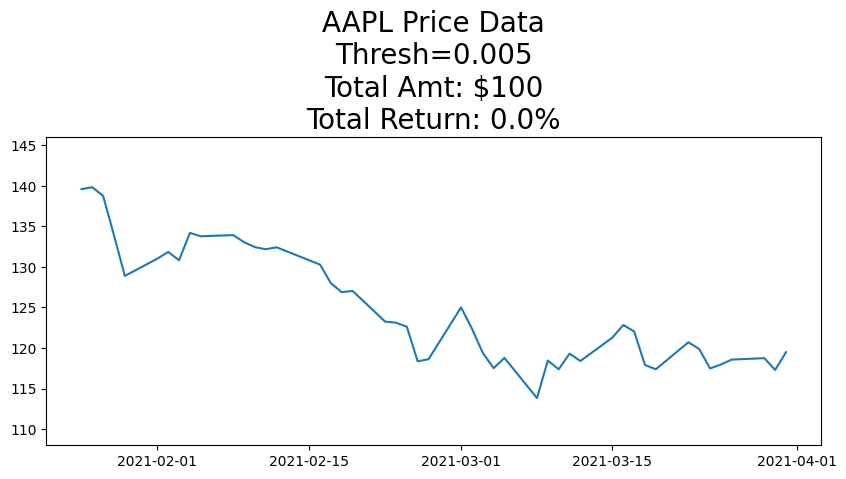

In [16]:
for thresh in [0, 0.001, 0.005]:
    run_simulation(returns, prices, 100, (5,0,5), thresh, verbose=False)